# Satellites and Space Debris: Exploratory Data Analysis

## Introduction

This notebook explores satellite and space debris data to understand the composition of the catalog and the relationships between object types, orbital characteristics, launch dates, and countries.

The analysis addresses four questions:

- How are cataloged objects distributed across orbital regions?
- How do satellites, rocket bodies, and debris differ in their orbital characteristics?
- How does the composition of the catalog vary across responsible country/entity codes and launch years?
- What data quality issues should be addressed before further analysis and modeling?

This is the first of three notebooks covering exploratory analysis, data cleaning, and supervised and unsupervised learning.

**Original project:** Ana Paula Cobresí, Gonzalo Angaut, Javier Albiero, and Octavio Santi.  
**Portfolio adaptation:** Gonzalo Angaut.

## Data Sources

The analysis uses five files provided through the original project's [data repository](https://github.com/EnzoRg/space_debris/tree/1c49c73b92e84d3eba2c53f43313ed861d08f896/data/raw):

| File | Contents |
|---|---|
| `satellites.json` | Satellite records |
| `debris.json` | Space debris records |
| `rockets.json` | Rocket body records |
| `unknown.json` | Records with an unknown object type |
| `ucs-satellite-database.xlsx` | Additional satellite information from the Union of Concerned Scientists database |

The four JSON files share a common structure and can be combined into a single catalog. The UCS dataset provides additional information, including satellite purpose, launch mass, and expected lifetime. Records can be linked through their NORAD catalog identifiers.

The files are loaded from a fixed repository commit to keep the input data reproducible. The analysis describes these historical datasets; it does not represent a live inventory of objects in orbit.

## Initial Data Inspection

We begin by importing the libraries used for data inspection and visualization.

In [1]:
from enum import Enum

import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_columns = None

We load the four object catalogs and the auxiliary UCS dataset from the pinned source version.

In [2]:
# Use a fixed source version containing the original datasets.
SOURCE_COMMIT = "1c49c73b92e84d3eba2c53f43313ed861d08f896"
BASE_URL = (
    "https://raw.githubusercontent.com/EnzoRg/space_debris/"
    f"{SOURCE_COMMIT}/data/raw"
)

satellites_df = pd.read_json(f"{BASE_URL}/satellites.json")
debris_df = pd.read_json(f"{BASE_URL}/debris.json")
rockets_df = pd.read_json(f"{BASE_URL}/rockets.json")
unknown_df = pd.read_json(f"{BASE_URL}/unknown.json")
extra_data_df = pd.read_excel(f"{BASE_URL}/ucs-satellite-database.xlsx")

satellites_df.head()

,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,COMMENT,COMMENTCODE,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER
0,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,NaN,NaN,0,NaN,1,1958,1,A,Y,EXPLORER 1,1958-001A,4
1,1958-003A,6,PAYLOAD,EXPLORER 3,US,1958-03-26,AFETR,1958-06-28,103.60,33.50,1739.0,117.0,NaN,5.0,0,NaN,1,1958,3,A,Y,EXPLORER 3,1958-003A,6
2,1958-004B,8,PAYLOAD,SPUTNIK 3,CIS,1958-05-15,TTMTR,1960-04-06,88.43,65.06,255.0,139.0,NaN,NaN,0,LARGE,1,1958,4,B,Y,SPUTNIK 3,1958-004B,8
3,1958-005A,9,PAYLOAD,EXPLORER 4,US,1958-07-26,AFETR,1959-10-23,92.81,50.25,585.0,239.0,NaN,NaN,0,NaN,1,1958,5,A,Y,EXPLORER 4,1958-005A,9
4,1958-006A,10,PAYLOAD,SCORE,US,1958-12-18,AFETR,1959-01-21,98.21,32.29,1187.0,159.0,NaN,NaN,0,NaN,1,1958,6,A,Y,SCORE,1958-006A,10


Before combining the object catalogs, we inspect the dimensions of each dataset and check whether the four JSON files contain the same columns.

In [3]:
object_catalogs = {
    "Satellites": satellites_df,
    "Debris": debris_df,
    "Rocket bodies": rockets_df,
    "Unknown objects": unknown_df,
}

# Summarize the dimensions of all input datasets.
datasets = {**object_catalogs, "UCS satellites": extra_data_df}

dataset_summary = pd.DataFrame(
    [
        {"Dataset": name, "Rows": len(df), "Columns": df.shape[1]}
        for name, df in datasets.items()
    ]
).set_index("Dataset")

display(dataset_summary)

# Compare column names against the satellite catalog.
reference_columns = set(satellites_df.columns)

for name, df in object_catalogs.items():
    missing_columns = reference_columns - set(df.columns)
    additional_columns = set(df.columns) - reference_columns

    print(f"{name}:")
    print(f"  Missing columns: {sorted(missing_columns)}")
    print(f"  Additional columns: {sorted(additional_columns)}")

,Rows,Columns
Dataset,,
Satellites,20328,24
Debris,35606,24
Rocket bodies,6699,24
Unknown objects,888,24
UCS satellites,7560,68


Satellites:
  Missing columns: []
  Additional columns: []
Debris:
  Missing columns: []
  Additional columns: []
Rocket bodies:
  Missing columns: []
  Additional columns: []
Unknown objects:
  Missing columns: []
  Additional columns: []


### Combining the Object Catalogs

The four object catalogs contain the same 24 columns and a total of 63,521 records. We concatenate them into a single table and check the object-type labels associated with each source.

The UCS satellite dataset is kept separate at this stage because it contains additional attributes and requires a merge using satellite identifiers.

In [4]:
# Combine the four catalogs and create a continuous row index.
space_objects_df = pd.concat(
    object_catalogs.values(),
    ignore_index=True,
)

# Verify that concatenation preserves the total number of records.
expected_rows = sum(len(df) for df in object_catalogs.values())
assert len(space_objects_df) == expected_rows, "Unexpected row count."

print(f"Combined catalog: {space_objects_df.shape[0]:,} rows")
print(f"Columns: {space_objects_df.shape[1]}")

display(space_objects_df.head())

Combined catalog: 63,521 rows
Columns: 24


,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,APOGEE,PERIGEE,COMMENT,COMMENTCODE,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER
0,1958-001A,4,PAYLOAD,EXPLORER 1,US,1958-02-01,AFETR,1970-03-31,88.48,33.15,215.0,183.0,NaN,NaN,0,NaN,1,1958,1,A,Y,EXPLORER 1,1958-001A,4
1,1958-003A,6,PAYLOAD,EXPLORER 3,US,1958-03-26,AFETR,1958-06-28,103.60,33.50,1739.0,117.0,NaN,5.0,0,NaN,1,1958,3,A,Y,EXPLORER 3,1958-003A,6
2,1958-004B,8,PAYLOAD,SPUTNIK 3,CIS,1958-05-15,TTMTR,1960-04-06,88.43,65.06,255.0,139.0,NaN,NaN,0,LARGE,1,1958,4,B,Y,SPUTNIK 3,1958-004B,8
3,1958-005A,9,PAYLOAD,EXPLORER 4,US,1958-07-26,AFETR,1959-10-23,92.81,50.25,585.0,239.0,NaN,NaN,0,NaN,1,1958,5,A,Y,EXPLORER 4,1958-005A,9
4,1958-006A,10,PAYLOAD,SCORE,US,1958-12-18,AFETR,1959-01-21,98.21,32.29,1187.0,159.0,NaN,NaN,0,NaN,1,1958,6,A,Y,SCORE,1958-006A,10


In [5]:
# Inspect object-type labels in each source, including missing values.
object_type_counts = pd.concat(
    {
        name: df["OBJECT_TYPE"].value_counts(dropna=False)
        for name, df in object_catalogs.items()
    },
    axis=1,
).fillna(0).astype(int)

object_type_counts.index.name = "Object type"
display(object_type_counts)

,Satellites,Debris,Rocket bodies,Unknown objects
Object type,,,,
PAYLOAD,20328,0,0,0
DEBRIS,0,35606,0,0
ROCKET BODY,0,0,6699,0
UNKNOWN,0,0,0,888


Each source file contains only its expected object type, with no missing type labels. The `OBJECT_TYPE` column therefore identifies the four groups in the combined catalog. The `PAYLOAD` label does not imply that a satellite is still operational.

### Checking Identifiers and Duplicate Records

The object catalog uses `NORAD_CAT_ID` to identify objects, while the UCS dataset uses `NORAD Number`. Before linking the datasets, we check for missing identifiers, repeated identifiers, and fully duplicated rows.

Repeated identifiers may correspond to identical records or to records with conflicting information, so they require inspection before removal.

In [6]:
# Check identifier completeness and uniqueness in both datasets.
identifier_sources = {
    "Object catalog": (space_objects_df, "NORAD_CAT_ID"),
    "UCS satellites": (extra_data_df, "NORAD Number"),
}

identifier_summary = []

for name, (df, id_column) in identifier_sources.items():
    ids = df[id_column]
    valid_ids = ids.dropna()

    identifier_summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Missing IDs": ids.isna().sum(),
        "Unique IDs": valid_ids.nunique(),
        "Rows with repeated IDs": valid_ids.duplicated(keep=False).sum(),
        "Exact duplicate rows": df.duplicated().sum(),
    })

display(pd.DataFrame(identifier_summary).set_index("Dataset"))

,Rows,Missing IDs,Unique IDs,Rows with repeated IDs,Exact duplicate rows
Dataset,,,,,
Object catalog,63521,0,63521,0,0
UCS satellites,7560,0,7551,18,7


The object catalog contains 63,521 unique identifiers, with no missing IDs or duplicate rows.

The UCS dataset contains nine identifiers that each appear twice. Seven rows are exact duplicates and can be removed without losing information. The remaining repeated identifiers require further inspection because their records differ.

In [7]:
# Remove exact duplicate rows while preserving the original dataset.
extra_data_clean_df = extra_data_df.drop_duplicates().copy()

# Inspect all records whose identifiers remain repeated.
repeated_id_mask = extra_data_clean_df["NORAD Number"].duplicated(
    keep=False
)

conflicting_records = (
    extra_data_clean_df.loc[repeated_id_mask]
    .sort_values("NORAD Number")
)

print(f"Rows after removing exact duplicates: {len(extra_data_clean_df):,}")

display(
    conflicting_records[
        [
            "NORAD Number",
            "Name of Satellite, Alternate Names",
            "Date of Launch",
            "Class of Orbit",
            "Purpose",
        ]
    ]
)

Rows after removing exact duplicates: 7,553


,NORAD Number,"Name of Satellite, Alternate Names",Date of Launch,Class of Orbit,Purpose
6621,54766,Starlink-5471,2022-12-17 00:00:00,LEO,Communications
6622,54766,Starlink-5472,2022-12-17 00:00:00,LEO,Communications
6744,55455,Starlink-5636,2023-02-02 00:00:00,LEO,Communications
6787,55455,Starlink-5680,2023-02-02 00:00:00,LEO,Communications


In [8]:
# Compare conflicting UCS records with names in the object catalog.
conflicting_ids = conflicting_records["NORAD Number"].unique()

catalog_reference = space_objects_df.loc[
    space_objects_df["NORAD_CAT_ID"].isin(conflicting_ids),
    ["NORAD_CAT_ID", "SATNAME"],
]

name_comparison = conflicting_records[
    ["NORAD Number", "Name of Satellite, Alternate Names"]
].merge(
    catalog_reference,
    left_on="NORAD Number",
    right_on="NORAD_CAT_ID",
    how="left",
    validate="many_to_one",
)

display(
    name_comparison[
        ["NORAD Number", "Name of Satellite, Alternate Names", "SATNAME"]
    ]
)

,NORAD Number,"Name of Satellite, Alternate Names",SATNAME
0,54766,Starlink-5471,STARLINK-5471
1,54766,Starlink-5472,STARLINK-5471
2,55455,Starlink-5636,STARLINK-5680
3,55455,Starlink-5680,STARLINK-5680


For the two conflicting identifiers, we retain the UCS record whose satellite name matches the object catalog: Starlink-5471 for NORAD 54766 and Starlink-5680 for NORAD 55455. Name comparisons ignore capitalization and surrounding whitespace.

This resolves the duplicate identifiers using consistency between the two datasets.

In [9]:
# Match satellite names only for records with repeated identifiers.
catalog_names = catalog_reference.set_index("NORAD_CAT_ID")["SATNAME"]

ucs_names = (
    extra_data_clean_df["Name of Satellite, Alternate Names"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

reference_names = (
    extra_data_clean_df["NORAD Number"]
    .map(catalog_names)
    .astype("string")
    .str.strip()
    .str.casefold()
)

name_matches = ucs_names.eq(reference_names).fillna(False)
keep_mask = ~repeated_id_mask | name_matches

final_extra_data_df = extra_data_clean_df.loc[keep_mask].copy()

# Verify that every identifier is preserved and appears exactly once.
assert final_extra_data_df["NORAD Number"].is_unique
assert (
    final_extra_data_df["NORAD Number"].nunique()
    == extra_data_clean_df["NORAD Number"].nunique()
)

print(f"UCS records after duplicate resolution: {len(final_extra_data_df):,}")

UCS records after duplicate resolution: 7,551


### Enriching the Object Catalog

We link the object catalog to selected UCS attributes using NORAD identifiers. A left join preserves all records in the object catalog and adds satellite information wherever a matching UCS record is available.

Objects without a UCS match retain missing values in the added columns. We also record whether each object has a matching UCS entry to distinguish unmatched records from missing attributes within matched records.

In [10]:
# Select UCS attributes and standardize their column names.
ucs_column_names = {
    "NORAD Number": "NORAD_NUMBER",
    "Class of Orbit": "CLASS_OF_ORBIT",
    "Type of Orbit": "TYPE_OF_ORBIT",
    "Purpose": "PURPOSE",
    "Expected Lifetime (yrs.)": "EXPECTED_LIFETIME_YRS",
    "Country of Operator/Owner": "COUNTRY_OF_OPERATOR_OWNER",
    "Users": "USERS",
    "Launch Mass (kg.)": "LAUNCH_MASS_KG",
}

ucs_selected_df = final_extra_data_df[
    list(ucs_column_names)
].rename(columns=ucs_column_names)

# Preserve all catalog objects and add matching UCS information.
space_objects_full_df = space_objects_df.merge(
    ucs_selected_df,
    how="left",
    left_on="NORAD_CAT_ID",
    right_on="NORAD_NUMBER",
    validate="one_to_one",
    indicator="UCS_MATCH",
)

space_objects_full_df["HAS_UCS_DATA"] = (
    space_objects_full_df["UCS_MATCH"] == "both"
)
space_objects_full_df = space_objects_full_df.drop(columns="UCS_MATCH")

assert len(space_objects_full_df) == len(space_objects_df)

# Summarize matching coverage for each object type.
merge_summary = (
    space_objects_full_df.groupby("OBJECT_TYPE")["HAS_UCS_DATA"]
    .agg(Total_records="size", Matched_with_UCS="sum")
)

merge_summary["Coverage_pct"] = (
    100 * merge_summary["Matched_with_UCS"]
    / merge_summary["Total_records"]
).round(2)

display(merge_summary)

,Total_records,Matched_with_UCS,Coverage_pct
OBJECT_TYPE,,,
DEBRIS,35606,15,0.04
PAYLOAD,20328,7369,36.25
ROCKET BODY,6699,7,0.10
UNKNOWN,888,160,18.02


In [11]:
# Inspect UCS matches outside the PAYLOAD category.
non_payload_matches = space_objects_full_df.loc[
    space_objects_full_df["HAS_UCS_DATA"]
    & space_objects_full_df["OBJECT_TYPE"].ne("PAYLOAD"),
    ["NORAD_CAT_ID", "SATNAME", "OBJECT_TYPE"],
].merge(
    final_extra_data_df[
        ["NORAD Number", "Name of Satellite, Alternate Names"]
    ],
    how="left",
    left_on="NORAD_CAT_ID",
    right_on="NORAD Number",
    validate="one_to_one",
)

# Display a small sample from each object type.
display(
    non_payload_matches
    .groupby("OBJECT_TYPE", sort=True)
    .head(5)
    .drop(columns="NORAD Number")
)

,NORAD_CAT_ID,SATNAME,OBJECT_TYPE,"Name of Satellite, Alternate Names"
0,38908,BREEZE-M DEB,DEBRIS,Mandrake 2B
1,53808,FALCON 9 DEB,DEBRIS,Bluewalker 3
2,42922,MINOTAUR DEB,DEBRIS,DHFR (DARPA High Frequency Receiver)
3,46200,H-2A DEB,DEBRIS,Hawk-7C
4,53129,CZ-2C DEB,DEBRIS,Siwei Gaojing 2-02
15,48275,CZ-5B R/B,ROCKET BODY,Tianhe
16,49392,CZ-2D R/B,ROCKET BODY,Yaogan 35C (Remote Sensing Satellite 35C)
17,22491,PEGASUS R/B,ROCKET BODY,SCD-1 (Satélite de Coleta de Dados)
18,43656,CZ-4B R/B,ROCKET BODY,Tangguo Guan (Candy Can)
19,52146,FREGAT R/B,ROCKET BODY,Meridian-10 (Meridian 20L)


### Dataset Used for the Exploratory Analysis

The UCS dataset provides additional attributes for 36.25% of the records labeled as `PAYLOAD`. However, some identifier matches associate debris or rocket bodies with named satellites, indicating inconsistencies that require further investigation.

We therefore continue this exploratory analysis using `space_objects_df`, the combined object catalog. This preserves a consistent set of attributes across all four object types.

UCS integration will be revisited in the data-cleaning notebook, where matching inconsistencies and attribute coverage will be assessed before using the additional information for modeling.

## Data Analysis and Visualization

We begin the exploratory analysis by examining how cataloged objects are distributed across orbital regions and object types.

The first questions we address are:

- How are cataloged objects distributed across orbital regions?
- How many objects belong to each object type?

Orbital regimes cannot always be determined from altitude alone. In particular, eccentric orbits may span multiple altitude ranges, while geostationary orbits require additional orbital properties beyond their altitude.

We therefore first inspect the orbital variables available in the catalog before defining the classification used in this analysis.

In [12]:
# Inspect the orbital variables available in the catalog.
orbital_keywords = [
    "PERIGEE",
    "APOGEE",
    "ECCENTRICITY",
    "INCLINATION",
    "PERIOD",
]

orbital_columns = [
    column
    for column in space_objects_df.columns
    if any(keyword in column.upper() for keyword in orbital_keywords)
]

print("Available orbital variables:")
print(orbital_columns)

# Summarize their coverage and basic statistics.
display(
    space_objects_df[orbital_columns]
    .describe()
    .T
    .assign(
        Missing=lambda df: [
            space_objects_df[column].isna().sum()
            for column in orbital_columns
        ]
    )
)

Available orbital variables:
['PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE']


,count,mean,std,min,25%,50%,75%,max,Missing
PERIOD,62548.0,178.561298,677.556733,0.0,89.26,94.11,101.2000,95687.68,973
INCLINATION,62548.0,69.017070,25.077595,0.0,53.02,70.36,95.1825,153.20,973
APOGEE,62548.0,3575.042767,13849.022354,0.0,267.00,486.00,882.0000,641287.00,973
PERIGEE,62548.0,1749.496707,6695.829135,0.0,196.00,410.00,676.0000,288019.00,973


### Orbital Data Quality

Orbital information is available for most objects in the catalog. Before assigning objects to orbital regions, we examine whether the missing values occur in the same records and inspect objects with zero-valued orbital parameters.

This step prevents missing or potentially invalid measurements from being interpreted as physical orbital characteristics.

In [13]:
orbital_columns = ["PERIOD", "INCLINATION", "APOGEE", "PERIGEE"]

# Check whether orbital variables are missing in the same records.
orbital_missing = space_objects_df[orbital_columns].isna()

missing_pattern = (
    orbital_missing
    .value_counts()
    .rename("Records")
    .reset_index()
)

display(missing_pattern)

,PERIOD,INCLINATION,APOGEE,PERIGEE,Records
0,False,False,False,False,62548
1,True,True,True,True,973


In [14]:
# Inspect records with zero-valued orbital parameters.
zero_orbit_mask = (
    space_objects_df["PERIGEE"].eq(0)
    | space_objects_df["APOGEE"].eq(0)
    | space_objects_df["PERIOD"].eq(0)
)

zero_orbit_summary = (
    space_objects_df.loc[zero_orbit_mask]
    .groupby("OBJECT_TYPE", dropna=False)
    .size()
    .rename("Records")
    .to_frame()
)

print(
    f"Objects with at least one zero-valued orbital parameter: "
    f"{zero_orbit_mask.sum():,}"
)

display(zero_orbit_summary)

display(
    space_objects_df.loc[
        zero_orbit_mask,
        [
            "SATNAME",
            "OBJECT_TYPE",
            "PERIGEE",
            "APOGEE",
            "PERIOD",
            "INCLINATION",
            "DECAY",
        ],
    ].head(10)
)

Objects with at least one zero-valued orbital parameter: 47


,Records
OBJECT_TYPE,
DEBRIS,31
PAYLOAD,8
ROCKET BODY,8


,SATNAME,OBJECT_TYPE,PERIGEE,APOGEE,PERIOD,INCLINATION,DECAY
2051,ORION EFT-1,PAYLOAD,0.0,5795.0,147.78,28.76,2014-12-05
2595,GENESIS SRC,PAYLOAD,0.0,373237.0,95687.68,52.05,2004-09-08
2808,USERS (REENTRY MODULE),PAYLOAD,0.0,0.0,0.00,0.00,2003-05-29
3169,HAYABUSA (MUSES C),PAYLOAD,0.0,0.0,0.00,0.00,2010-06-13
3668,MESSENGER,PAYLOAD,0.0,0.0,0.00,0.00,2015-04-30
4416,FLOCK 3M 4,PAYLOAD,0.0,0.0,83.81,97.43,2023-02-28
5927,STARLINK-1145,PAYLOAD,0.0,573.0,88.04,52.25,2025-01-29
6818,CLUSTER II-FM6,PAYLOAD,0.0,132481.0,3241.80,150.07,2024-09-08
28505,DELTA 4 DEB,DEBRIS,0.0,5795.0,147.78,28.76,2014-12-05
37692,FENGYUN 1C DEB,DEBRIS,0.0,631.0,79.65,98.42,2017-05-05


In [15]:
# Check whether zero-valued or missing orbital data are associated with decayed objects.
orbit_status_summary = pd.DataFrame({
    "Zero-valued orbit": zero_orbit_mask,
    "Missing orbital data": space_objects_df[orbital_columns].isna().any(axis=1),
    "Decayed": space_objects_df["DECAY"].notna(),
})

display(
    orbit_status_summary
    .value_counts()
    .rename("Records")
    .reset_index()
    .sort_values("Records", ascending=False)
)

,Zero-valued orbit,Missing orbital data,Decayed,Records
0,False,False,True,33069
1,False,False,False,29432
2,False,True,False,647
3,False,True,True,326
4,True,False,True,47


All 47 records containing zero-valued orbital parameters correspond to objects with a recorded decay date. Missing orbital data, however, are not restricted to decayed objects.

For the orbital-regime analysis, we therefore focus on objects with no recorded decay date and complete, positive orbital parameters. The full catalog is retained for analyses where historical or decayed objects are relevant.

In [16]:
# Select non-decayed objects with complete and positive orbital information.
orbital_analysis_df = space_objects_df.loc[
    space_objects_df["DECAY"].isna()
    & space_objects_df[orbital_columns].notna().all(axis=1)
    & space_objects_df["PERIGEE"].gt(0)
    & space_objects_df["APOGEE"].gt(0)
    & space_objects_df["PERIOD"].gt(0)
].copy()

print(
    f"Objects retained for orbital analysis: "
    f"{len(orbital_analysis_df):,} "
    f"({100 * len(orbital_analysis_df) / len(space_objects_df):.1f}% of the catalog)"
)

Objects retained for orbital analysis: 29,432 (46.3% of the catalog)


In [17]:
# Check basic consistency between perigee and apogee.
invalid_altitude_order = (
    orbital_analysis_df["APOGEE"]
    < orbital_analysis_df["PERIGEE"]
)

print(
    f"Records with apogee lower than perigee: "
    f"{invalid_altitude_order.sum():,}"
)

display(
    orbital_analysis_df.loc[
        invalid_altitude_order,
        [
            "SATNAME",
            "OBJECT_TYPE",
            "PERIGEE",
            "APOGEE",
            "PERIOD",
            "INCLINATION",
        ],
    ].head(10)
)

Records with apogee lower than perigee: 0


,SATNAME,OBJECT_TYPE,PERIGEE,APOGEE,PERIOD,INCLINATION


### Orbital Regime Classification

We classify objects according to both perigee and apogee altitude rather than using perigee alone.

This distinction is important for eccentric orbits, which may cross more than one altitude regime. Objects whose entire orbit lies within a single altitude range are assigned to that region, while objects spanning multiple regions are labeled as `Crossing`.

For the geosynchronous-altitude region, we use a ±1,000 km band around 35,786 km. We refer to this category as `GEO-like` because altitude alone is not sufficient to establish that an orbit is truly geostationary.

In [18]:
class OrbitRegion(Enum):
    LEO_MAX = 2_000
    GEO_MIN = 34_786
    GEO_MAX = 36_786


def classify_orbit(row: pd.Series) -> str:
    """
    Classify an orbit using both perigee and apogee altitude.

    Orbits spanning more than one altitude regime are labeled as Crossing.
    """
    perigee = row["PERIGEE"]
    apogee = row["APOGEE"]

    if apogee <= OrbitRegion.LEO_MAX.value:
        return "LEO"

    if (
        perigee > OrbitRegion.LEO_MAX.value
        and apogee < OrbitRegion.GEO_MIN.value
    ):
        return "MEO"

    if (
        perigee >= OrbitRegion.GEO_MIN.value
        and apogee <= OrbitRegion.GEO_MAX.value
    ):
        return "GEO-like"

    if perigee > OrbitRegion.GEO_MAX.value:
        return "High Earth"

    return "Crossing"


orbital_analysis_df["ORBIT_REGION"] = orbital_analysis_df.apply(
    classify_orbit,
    axis=1,
)

orbit_counts = (
    orbital_analysis_df["ORBIT_REGION"]
    .value_counts()
    .rename("Objects")
    .to_frame()
)

orbit_counts["Percentage"] = (
    100 * orbit_counts["Objects"] / len(orbital_analysis_df)
).round(2)

display(orbit_counts)

,Objects,Percentage
ORBIT_REGION,,
LEO,23556,80.04
Crossing,3381,11.49
GEO-like,1562,5.31
MEO,876,2.98
High Earth,57,0.19


In [19]:
# Verify that every object receives exactly one orbital-region label.
assert orbital_analysis_df["ORBIT_REGION"].notna().all()

print(
    f"Classified objects: "
    f"{orbital_analysis_df['ORBIT_REGION'].notna().sum():,}"
)

Classified objects: 29,432


Most objects included in the orbital analysis are located entirely within Low Earth Orbit (LEO), which accounts for approximately 80% of the classified records.

A further 11.5% of the objects follow orbits that cross more than one altitude regime. This group would be obscured by a classification based only on perigee altitude, highlighting the benefit of considering both perigee and apogee.

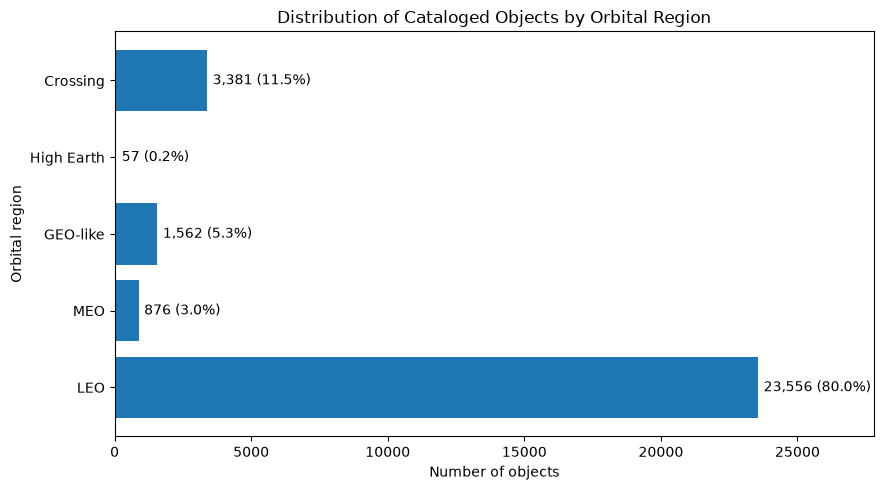

In [20]:
# Plot the number of objects in each orbital region.
orbit_order = ["LEO", "MEO", "GEO-like", "High Earth", "Crossing"]

orbit_plot = (
    orbital_analysis_df["ORBIT_REGION"]
    .value_counts()
    .reindex(orbit_order)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    orbit_plot.index,
    orbit_plot.values,
)

ax.bar_label(
    bars,
    labels=[
        f"{count:,} ({100 * count / len(orbital_analysis_df):.1f}%)"
        for count in orbit_plot.values
    ],
    padding=4,
)

ax.set_xlabel("Number of objects")
ax.set_ylabel("Orbital region")
ax.set_title("Distribution of Cataloged Objects by Orbital Region")

ax.set_xlim(0, orbit_plot.max() * 1.18)

plt.tight_layout()
plt.show()

We next examine the composition of the complete catalog by object type. Unlike the orbital-regime analysis, this comparison does not require orbital information, so all 63,521 catalog records are included.

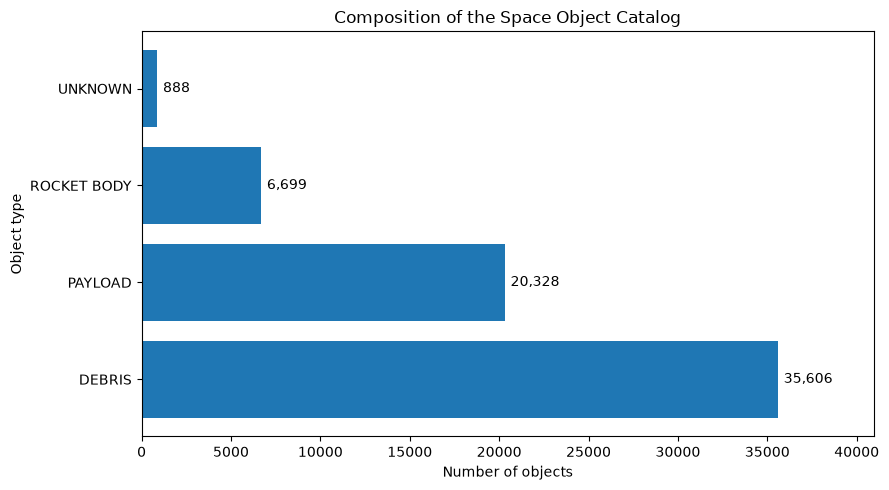

In [21]:
# Count objects by catalog type using the complete dataset.
object_type_counts = (
    space_objects_df["OBJECT_TYPE"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    object_type_counts.index,
    object_type_counts.values,
)

ax.bar_label(
    bars,
    labels=[f"{count:,}" for count in object_type_counts.values],
    padding=4,
)

ax.set_xlabel("Number of objects")
ax.set_ylabel("Object type")
ax.set_title("Composition of the Space Object Catalog")

ax.set_xlim(0, object_type_counts.max() * 1.15)

plt.tight_layout()
plt.show()

### Object Types Across Orbital Regions

The previous results show that most cataloged objects with valid current orbital data are located in LEO. We now examine whether the composition of the catalog also changes across orbital regions.

Comparing object types within each region helps distinguish regions dominated by payloads from those containing larger fractions of debris or rocket bodies.

In [22]:
# Count object types within each orbital region.
orbit_object_counts = pd.crosstab(
    orbital_analysis_df["ORBIT_REGION"],
    orbital_analysis_df["OBJECT_TYPE"],
)

orbit_object_counts = orbit_object_counts.reindex(orbit_order)

display(orbit_object_counts)

OBJECT_TYPE,DEBRIS,PAYLOAD,ROCKET BODY,UNKNOWN
ORBIT_REGION,,,,
LEO,10152,11877,944,583
MEO,260,423,191,2
GEO-like,66,1277,219,0
High Earth,5,46,6,0
Crossing,2262,285,834,0


In [23]:
# Compute the object-type composition within each orbital region.
object_type_order = [
    "PAYLOAD",
    "DEBRIS",
    "ROCKET BODY",
    "UNKNOWN",
]

orbit_object_counts = orbit_object_counts[object_type_order]

orbit_object_pct = (
    orbit_object_counts
    .div(orbit_object_counts.sum(axis=1), axis=0)
    .mul(100)
)

display(orbit_object_pct.round(1))

OBJECT_TYPE,PAYLOAD,DEBRIS,ROCKET BODY,UNKNOWN
ORBIT_REGION,,,,
LEO,50.4,43.1,4.0,2.5
MEO,48.3,29.7,21.8,0.2
GEO-like,81.8,4.2,14.0,0.0
High Earth,80.7,8.8,10.5,0.0
Crossing,8.4,66.9,24.7,0.0


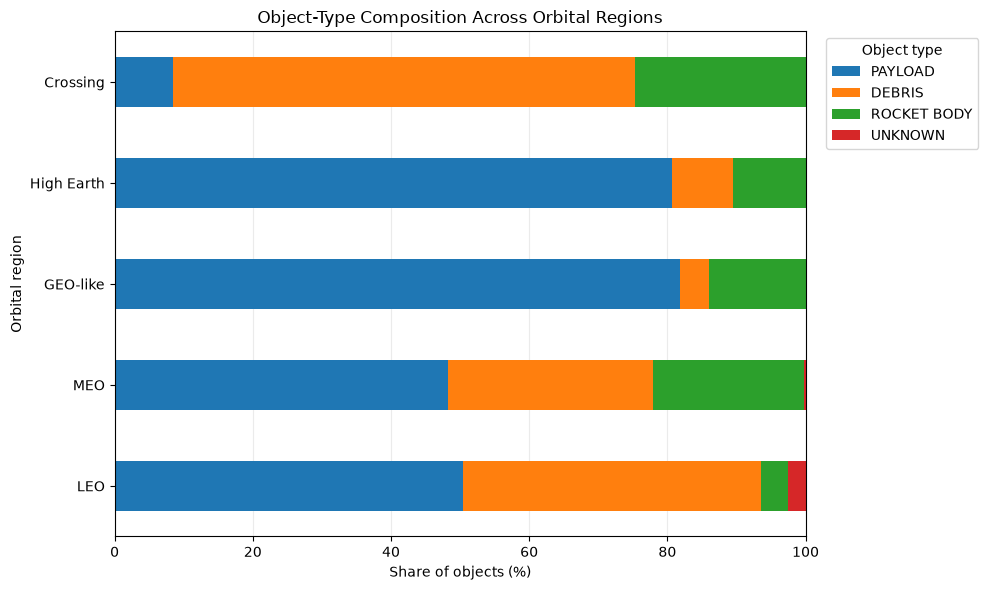

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

orbit_object_pct.plot(
    kind="barh",
    stacked=True,
    ax=ax,
)

ax.set_xlabel("Share of objects (%)")
ax.set_ylabel("Orbital region")
ax.set_title("Object-Type Composition Across Orbital Regions")
ax.set_xlim(0, 100)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.legend(
    title="Object type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

The composition of the catalog varies substantially across orbital regions.

LEO contains a relatively balanced mixture of payloads (50.4%) and debris (43.1%), whereas the GEO-like region is strongly dominated by payloads (81.8%).

Crossing orbits show a markedly different composition: debris accounts for 66.9% of these objects and rocket bodies for another 24.7%, while payloads represent only 8.4%.

The High Earth category is also dominated by payloads, although this result should be interpreted cautiously because the region contains only 57 objects.

### Evolution of the Space Object Population

After examining the current composition of the catalog, we turn to its evolution over time.

The `LAUNCH` and `LAUNCH_YEAR` variables allow us to study how the number and type of cataloged objects associated with launches have changed across decades.

We first inspect the temporal coverage and consistency of these variables before analyzing launch trends.

In [25]:
# Inspect launch-date coverage and consistency.
launch_summary = pd.Series({
    "Total records": len(space_objects_df),
    "Records with launch date": space_objects_df["LAUNCH"].notna().sum(),
    "Records with launch year": space_objects_df["LAUNCH_YEAR"].notna().sum(),
    "Earliest launch year": space_objects_df["LAUNCH_YEAR"].min(),
    "Latest launch year": space_objects_df["LAUNCH_YEAR"].max(),
})

display(launch_summary.to_frame("Value"))

display(
    space_objects_df[
        ["SATNAME", "OBJECT_TYPE", "LAUNCH", "LAUNCH_YEAR"]
    ].head()
)

,Value
Total records,63521
Records with launch date,63521
Records with launch year,63521
Earliest launch year,1957
Latest launch year,2025


,SATNAME,OBJECT_TYPE,LAUNCH,LAUNCH_YEAR
0,EXPLORER 1,PAYLOAD,1958-02-01,1958
1,EXPLORER 3,PAYLOAD,1958-03-26,1958
2,SPUTNIK 3,PAYLOAD,1958-05-15,1958
3,EXPLORER 4,PAYLOAD,1958-07-26,1958
4,SCORE,PAYLOAD,1958-12-18,1958


In [26]:
# Verify that LAUNCH_YEAR matches the year encoded in LAUNCH.
launch_dates = pd.to_datetime(space_objects_df["LAUNCH"], errors="coerce")

year_mismatch = (
    launch_dates.dt.year
    .ne(space_objects_df["LAUNCH_YEAR"])
)

print(f"Records with inconsistent launch year: {year_mismatch.sum():,}")

Records with inconsistent launch year: 0


Launch information is complete for all 63,521 records, covering objects associated with launches from 1957 to 2025.

In the following analysis, counts refer to **cataloged objects by launch year**, not to the number of launch events. A single launch may contribute multiple payloads, rocket bodies, or debris objects to the catalog.

In [27]:
# Check whether the latest year is fully represented in the dataset.
latest_launch_date = launch_dates.max()

print(f"Latest launch date in the catalog: {latest_launch_date.date()}")

latest_year = latest_launch_date.year

latest_year_counts = (
    space_objects_df.loc[
        space_objects_df["LAUNCH_YEAR"] == latest_year,
        "OBJECT_TYPE",
    ]
    .value_counts()
    .reindex(object_type_order, fill_value=0)
)

display(latest_year_counts.to_frame("Objects"))

Latest launch date in the catalog: 2025-04-22


,Objects
OBJECT_TYPE,
PAYLOAD,940
DEBRIS,3
ROCKET BODY,37
UNKNOWN,92


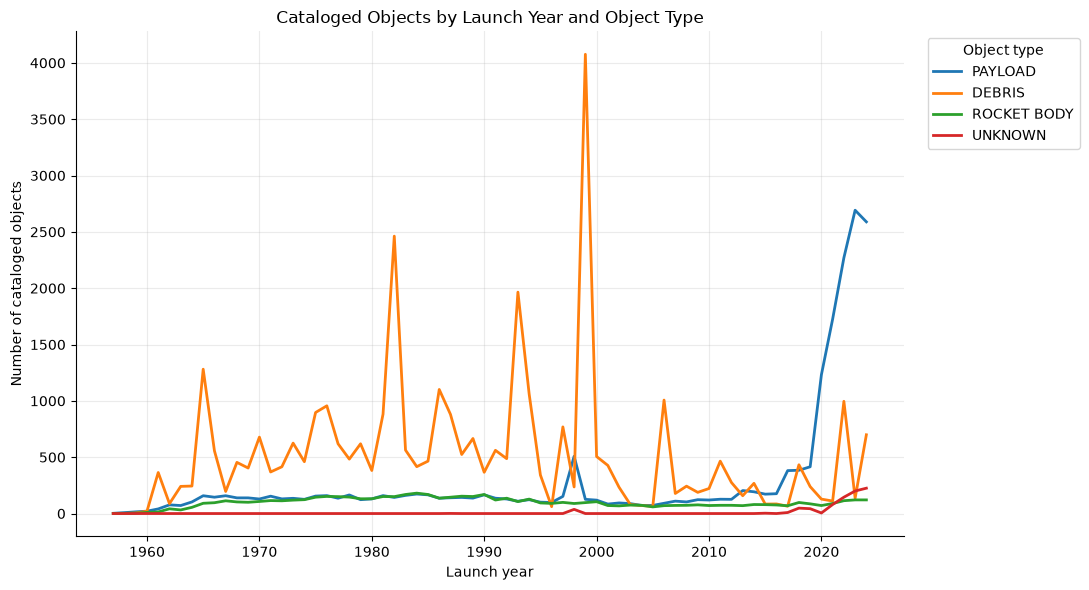

In [28]:
# Restrict the trend analysis to complete calendar years.
complete_years_df = space_objects_df.loc[
    space_objects_df["LAUNCH_YEAR"] < latest_year
].copy()

objects_by_year = (
    complete_years_df
    .groupby(["LAUNCH_YEAR", "OBJECT_TYPE"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=object_type_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 6))

for object_type in object_type_order:
    ax.plot(
        objects_by_year.index,
        objects_by_year[object_type],
        label=object_type,
        linewidth=2,
    )

ax.set_xlabel("Launch year")
ax.set_ylabel("Number of cataloged objects")
ax.set_title("Cataloged Objects by Launch Year and Object Type")

ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Object type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

The catalog includes launch records through April 22, 2025. Since 2025 is only partially represented, we exclude it from the year-by-year trend analysis to avoid interpreting incomplete coverage as a decline in activity.

The temporal analysis therefore uses complete years from 1957 through 2024.

### Launch Cohorts Associated with Cataloged Debris

The debris series contains several pronounced peaks associated with specific launch years. These peaks should not be interpreted as the years in which the debris was necessarily created.

For debris objects, `LAUNCH_YEAR` refers to the launch associated with the parent object. Fragmentation may have occurred later. We therefore interpret these values as **launch cohorts associated with the largest numbers of cataloged debris objects**.

In [29]:
# Identify launch years associated with the largest numbers of debris objects.
debris_by_year = (
    complete_years_df.loc[
        complete_years_df["OBJECT_TYPE"] == "DEBRIS"
    ]
    .groupby("LAUNCH_YEAR")
    .size()
    .sort_values(ascending=False)
)

display(
    debris_by_year
    .head(10)
    .rename("Debris objects")
    .to_frame()
)

,Debris objects
LAUNCH_YEAR,
1999,4076
1982,2462
1993,1965
1965,1281
1986,1101
1994,1061
2006,1007
2022,996
1976,956


In [30]:
# Count debris objects associated with each launch.
debris_df = complete_years_df.loc[
    complete_years_df["OBJECT_TYPE"] == "DEBRIS"
].copy()

debris_by_launch = (
    debris_df
    .groupby(["LAUNCH_YEAR", "LAUNCH_NUM"])
    .size()
    .rename("Debris objects")
    .reset_index()
    .sort_values("Debris objects", ascending=False)
)

# Build a readable international-launch identifier.
debris_by_launch["LAUNCH_ID"] = (
    debris_by_launch["LAUNCH_YEAR"].astype(int).astype(str)
    + "-"
    + debris_by_launch["LAUNCH_NUM"].astype(int).astype(str).str.zfill(3)
)

display(
    debris_by_launch[
        ["LAUNCH_ID", "Debris objects"]
    ].head(15)
)

,LAUNCH_ID,Debris objects
2240,1999-025,3534
1315,1982-092,1806
2038,1993-036,1716
3004,2022-151,793
2073,1994-029,753
3073,2024-140,669
2180,1997-051,656
2426,2006-026,508
1590,1986-019,498
1221,1981-053,478


In [31]:
# Summarize the largest debris-associated launch cohorts.
top_debris_cohorts = debris_by_launch.head(10).copy()

# Add the total number of debris objects associated with each launch year.
top_debris_cohorts["Year debris total"] = (
    top_debris_cohorts["LAUNCH_YEAR"]
    .map(debris_by_year)
)

top_debris_cohorts["Share of year's debris (%)"] = (
    100
    * top_debris_cohorts["Debris objects"]
    / top_debris_cohorts["Year debris total"]
).round(1)

# Extract the most common object-family name for each launch cohort.
representative_names = (
    debris_df
    .groupby(["LAUNCH_YEAR", "LAUNCH_NUM"])["SATNAME"]
    .agg(lambda names: names.mode().iloc[0])
    .rename("Representative name")
    .reset_index()
)

top_debris_cohorts = top_debris_cohorts.merge(
    representative_names,
    on=["LAUNCH_YEAR", "LAUNCH_NUM"],
    how="left",
)

display(
    top_debris_cohorts[
        [
            "LAUNCH_ID",
            "Representative name",
            "Debris objects",
            "Share of year's debris (%)",
        ]
    ]
)

,LAUNCH_ID,Representative name,Debris objects,Share of year's debris (%)
0,1999-025,FENGYUN 1C DEB,3534,86.7
1,1982-092,COSMOS 1408 DEB,1806,73.4
2,1993-036,COSMOS 2251 DEB,1716,87.3
3,2022-151,CZ-6A DEB,793,79.6
4,1994-029,PEGASUS DEB,753,71.0
5,2024-140,CZ-6A DEB,669,95.7
6,1997-051,IRIDIUM 33 DEB,656,85.3
7,2006-026,COSMOS 2421 DEB,508,50.4
8,1986-019,ARIANE 1 DEB,498,45.2
9,1981-053,COSMOS 1275 DEB,478,54.2


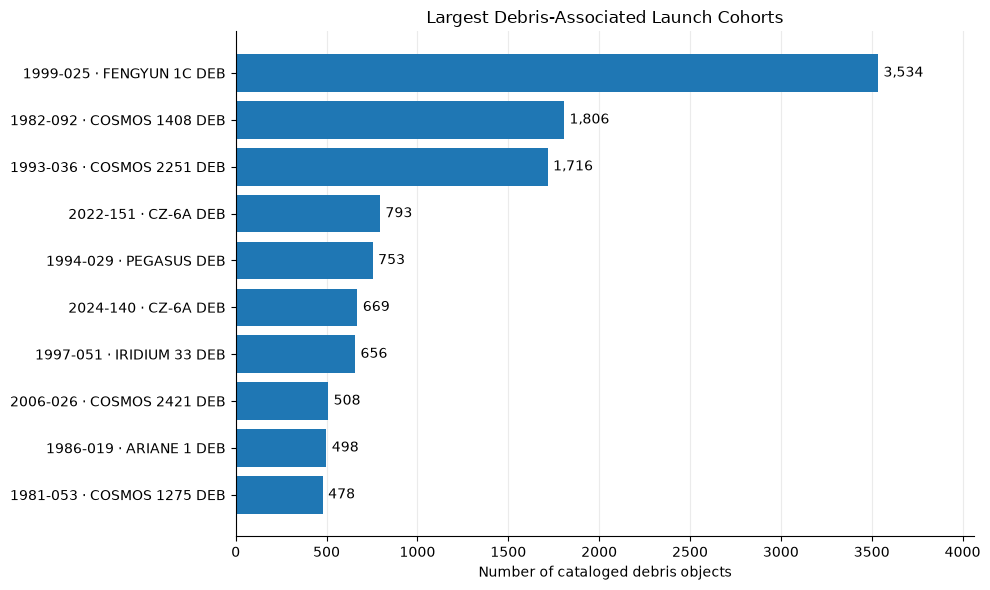

In [32]:
plot_data = (
    top_debris_cohorts
    .sort_values("Debris objects")
    .copy()
)

plot_data["Label"] = (
    plot_data["LAUNCH_ID"]
    + " · "
    + plot_data["Representative name"]
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_data["Label"],
    plot_data["Debris objects"],
)

ax.bar_label(
    bars,
    labels=[f"{value:,}" for value in plot_data["Debris objects"]],
    padding=4,
)

ax.set_xlabel("Number of cataloged debris objects")
ax.set_ylabel("")
ax.set_title("Largest Debris-Associated Launch Cohorts")

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(
    0,
    plot_data["Debris objects"].max() * 1.15,
)

plt.tight_layout()
plt.show()

The largest annual debris peaks are strongly concentrated in a small number of launch cohorts rather than being distributed uniformly across launches.

For example, launch cohort `1999-025` accounts for 3,534 cataloged debris objects, representing approximately 87% of all debris associated with the 1999 launch year. Similar concentration is observed for the largest cohorts associated with 1982 and 1993.

This suggests that a relatively small number of parent-object cohorts contribute disproportionately to the cataloged debris population. The launch year identifies the cohort associated with the debris and should not be interpreted as the date on which fragmentation necessarily occurred.

### Growth in Payload Deployment

The temporal trend shows a sharp increase in cataloged payloads during the most recent years.

To better understand this growth, we compare the number of payload objects with the number of launch events associated with each year. This allows us to distinguish between an increase in launch activity and an increase in the number of payloads deployed per launch.

In [33]:
# Build a launch identifier from launch year and launch number.
complete_years_df["LAUNCH_ID"] = (
    complete_years_df["LAUNCH_YEAR"].astype(int).astype(str)
    + "-"
    + complete_years_df["LAUNCH_NUM"].astype(int).astype(str).str.zfill(3)
)

payload_df = complete_years_df.loc[
    complete_years_df["OBJECT_TYPE"] == "PAYLOAD"
].copy()

In [34]:
# Summarize payload deployment by launch year.
payloads_by_year = (
    payload_df
    .groupby("LAUNCH_YEAR")
    .size()
    .rename("Payloads")
)

# Count launch events containing at least one payload.
payload_launches_by_year = (
    payload_df
    .groupby("LAUNCH_YEAR")["LAUNCH_ID"]
    .nunique()
    .rename("Payload launches")
)

payload_launch_summary = pd.concat(
    [payloads_by_year, payload_launches_by_year],
    axis=1,
).fillna(0)

payload_launch_summary["Payloads per payload launch"] = (
    payload_launch_summary["Payloads"]
    / payload_launch_summary["Payload launches"]
)

display(payload_launch_summary.tail(15).round(2))

,Payloads,Payload launches,Payloads per payload launch
LAUNCH_YEAR,,,
2010,120,70,1.71
2011,127,80,1.59
2012,126,75,1.68
2013,204,78,2.62
2014,193,90,2.14
2015,172,83,2.07
2016,176,83,2.12
2017,381,86,4.43
2018,384,112,3.43


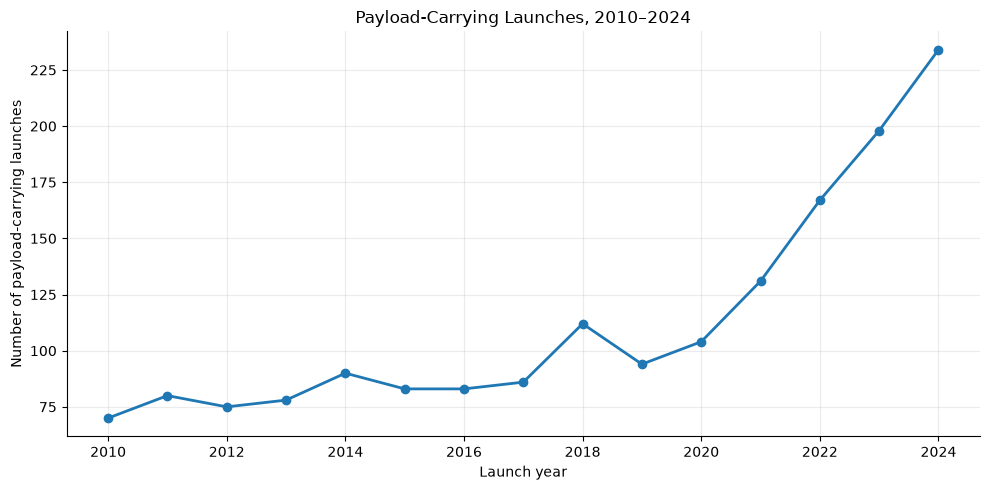

In [35]:
recent_payload_summary = payload_launch_summary.loc[2010:2024]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    recent_payload_summary.index,
    recent_payload_summary["Payload launches"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Launch year")
ax.set_ylabel("Number of payload-carrying launches")
ax.set_title("Payload-Carrying Launches, 2010–2024")

ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

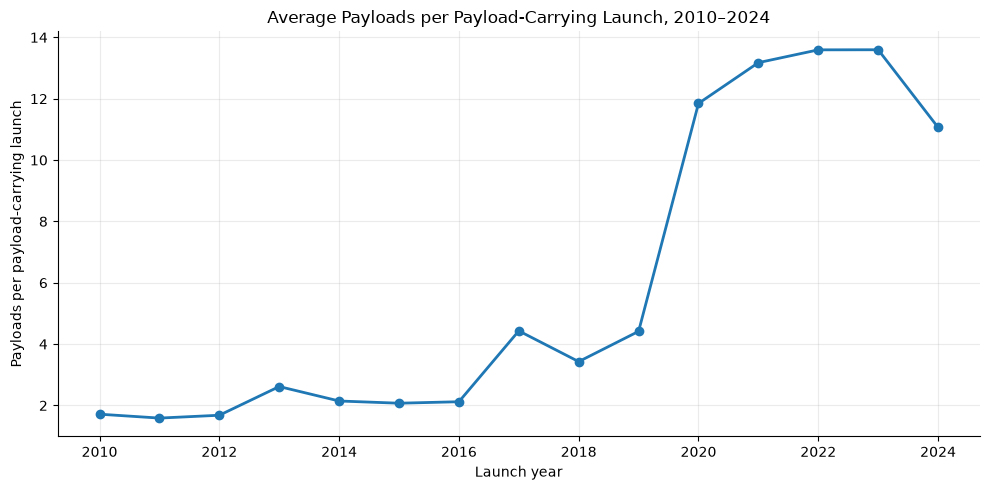

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    recent_payload_summary.index,
    recent_payload_summary["Payloads per payload launch"],
    marker="o",
    linewidth=2,
)

ax.set_xlabel("Launch year")
ax.set_ylabel("Payloads per payload-carrying launch")
ax.set_title("Average Payloads per Payload-Carrying Launch, 2010–2024")

ax.grid(alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The recent increase in cataloged payloads reflects two simultaneous trends.

The number of launches carrying at least one payload increased from 70 in 2010 to 234 in 2024. Over the same period, the average number of payloads associated with each payload-carrying launch increased from 1.71 to 11.06.

As a result, the growth in payload deployment is not explained by launch frequency alone. The increasing number of payloads per launch contributes substantially to the rapid rise in cataloged payloads observed in recent years.

### Geographic Distribution

The catalog includes two geographic variables:

- `COUNTRY`: the code associated with the country or entity responsible for the object.
- `SITE`: the launch-site code associated with the object's launch.

Both variables are complete across the catalog. However, `COUNTRY` is not restricted to modern sovereign states: some codes represent historical groupings or international organizations. We therefore treat it as a **responsible country/entity code** rather than as a strictly geopolitical country classification.

In [37]:
# Identify the most represented responsible country/entity codes.
responsible_entity_counts = (
    space_objects_df["COUNTRY"]
    .value_counts()
)

top_responsible_entities = responsible_entity_counts.head(10)

display(
    top_responsible_entities
    .rename("Objects")
    .to_frame()
)

,Objects
COUNTRY,
CIS,24966
US,23584
PRC,8469
FR,1457
JPN,863
IND,754
UK,749
TBD,417
ESA,178


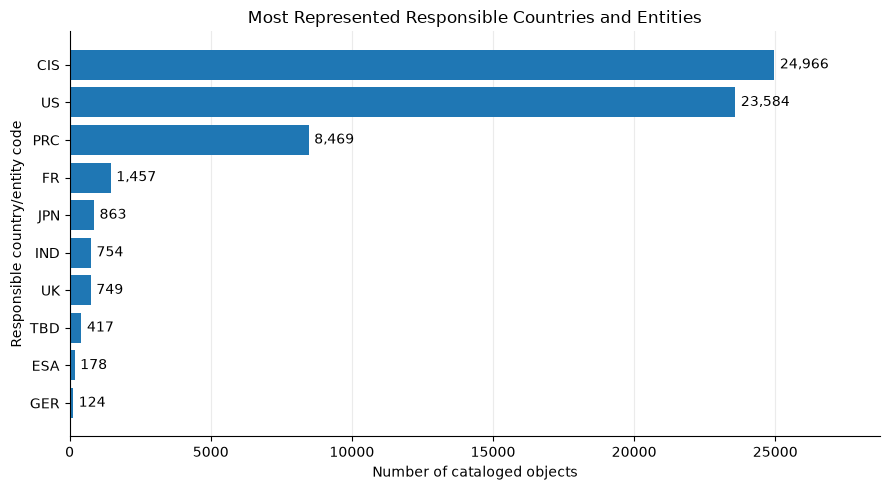

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = top_responsible_entities.sort_values()

bars = ax.barh(
    plot_data.index,
    plot_data.values,
)

ax.bar_label(
    bars,
    labels=[f"{value:,}" for value in plot_data.values],
    padding=4,
)

ax.set_xlabel("Number of cataloged objects")
ax.set_ylabel("Responsible country/entity code")
ax.set_title("Most Represented Responsible Countries and Entities")

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(0, plot_data.max() * 1.15)

plt.tight_layout()
plt.show()

The catalog is highly concentrated among a small number of responsible country/entity codes, with `CIS`, `US`, and `PRC` accounting for substantially more objects than the remaining entries.

However, total counts alone do not reveal whether these groups contribute similar types of objects. We therefore compare the composition of the largest identifiable responsible entities by object type.

In [39]:
# Select the most represented identifiable responsible entities.
top_entity_codes = (
    responsible_entity_counts
    .drop(index="TBD", errors="ignore")
    .head(7)
    .index
)

entity_object_counts = pd.crosstab(
    space_objects_df.loc[
        space_objects_df["COUNTRY"].isin(top_entity_codes),
        "COUNTRY",
    ],
    space_objects_df.loc[
        space_objects_df["COUNTRY"].isin(top_entity_codes),
        "OBJECT_TYPE",
    ],
)

entity_object_counts = (
    entity_object_counts
    .reindex(top_entity_codes)
    .reindex(columns=object_type_order, fill_value=0)
)

display(entity_object_counts)

OBJECT_TYPE,PAYLOAD,DEBRIS,ROCKET BODY,UNKNOWN
COUNTRY,,,,
CIS,3706,17229,3990,41
US,12356,9612,1591,25
PRC,1066,6451,570,382
FR,142,1058,257,0
JPN,317,399,138,9
IND,148,528,75,3
UK,744,4,1,0


In [40]:
# Compute the object-type composition within each responsible entity.
entity_object_pct = (
    entity_object_counts
    .div(entity_object_counts.sum(axis=1), axis=0)
    .mul(100)
)

display(entity_object_pct.round(1))

OBJECT_TYPE,PAYLOAD,DEBRIS,ROCKET BODY,UNKNOWN
COUNTRY,,,,
CIS,14.8,69.0,16.0,0.2
US,52.4,40.8,6.7,0.1
PRC,12.6,76.2,6.7,4.5
FR,9.7,72.6,17.6,0.0
JPN,36.7,46.2,16.0,1.0
IND,19.6,70.0,9.9,0.4
UK,99.3,0.5,0.1,0.0


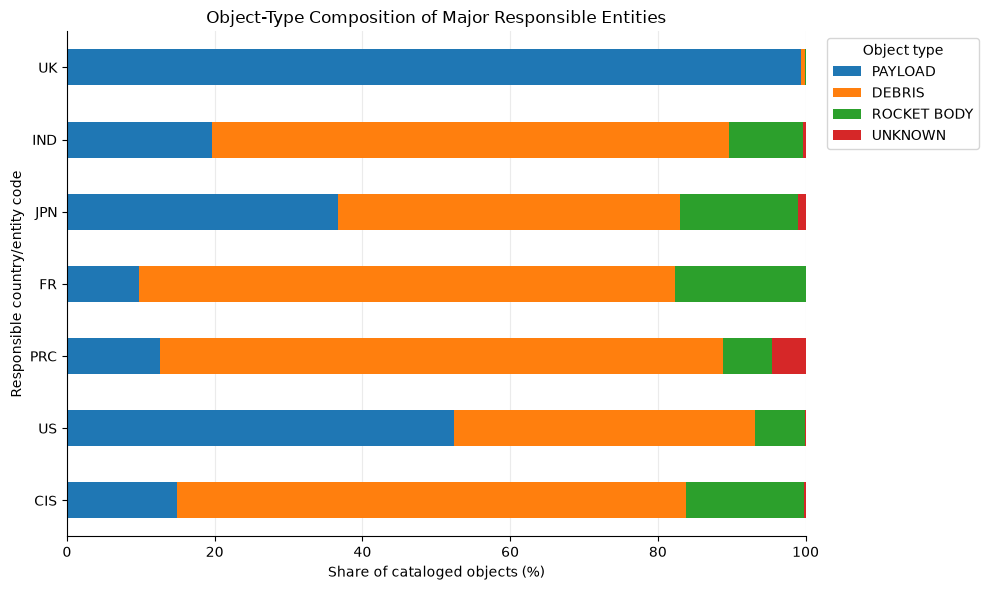

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

entity_object_pct.plot(
    kind="barh",
    stacked=True,
    ax=ax,
)

ax.set_xlabel("Share of cataloged objects (%)")
ax.set_ylabel("Responsible country/entity code")
ax.set_title("Object-Type Composition of Major Responsible Entities")
ax.set_xlim(0, 100)

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Object type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

The object-type composition differs markedly across the major responsible country/entity codes.

`CIS`, `PRC`, `FR`, and `IND` are strongly debris-dominated in this catalog, while the `US` distribution is more balanced between payloads and debris. `JPN` also shows a mixed composition.

The `UK` code is an extreme case, with almost all associated records classified as payloads. These differences describe the composition of the catalog under each responsibility code and should not be interpreted directly as measures of national launch activity or debris generation.

### Orbital Characteristics by Object Type

Beyond orbital-region labels, the catalog contains continuous orbital measurements such as perigee, apogee, inclination, and orbital period.

We next examine these variables directly to determine whether different object types occupy distinct regions of orbital-parameter space.

In [42]:
# Summarize orbital altitudes by object type.
orbital_altitude_summary = (
    orbital_analysis_df
    .groupby("OBJECT_TYPE")[["PERIGEE", "APOGEE"]]
    .agg(["median", "mean", "min", "max"])
)

display(orbital_altitude_summary.round(1))

PERIGEE                            APOGEE                  \
             median    mean    min       max   median     mean    min   
OBJECT_TYPE                                                             
DEBRIS        782.0  1437.0  112.0   37446.0    971.0   5382.7  245.0   
PAYLOAD       558.0  4777.6  137.0  288019.0    560.0   5811.1  148.0   
ROCKET BODY   892.0  7204.6  117.0  139944.0  17366.0  19173.8  220.0   
UNKNOWN       491.0   518.8  149.0    5835.0    504.0    543.2  162.0   

                       
                  max  
OBJECT_TYPE            
DEBRIS       322453.0  
PAYLOAD      572308.0  
ROCKET BODY  641287.0  
UNKNOWN        5866.0

The orbital-altitude distributions are strongly right-skewed: mean values are substantially larger than medians for several object types, indicating a relatively small number of very high-altitude orbits.

Rocket bodies are particularly notable: their median apogee is much larger than their median perigee, suggesting that many occupy highly elongated orbits. We examine this structure directly by plotting perigee against apogee.

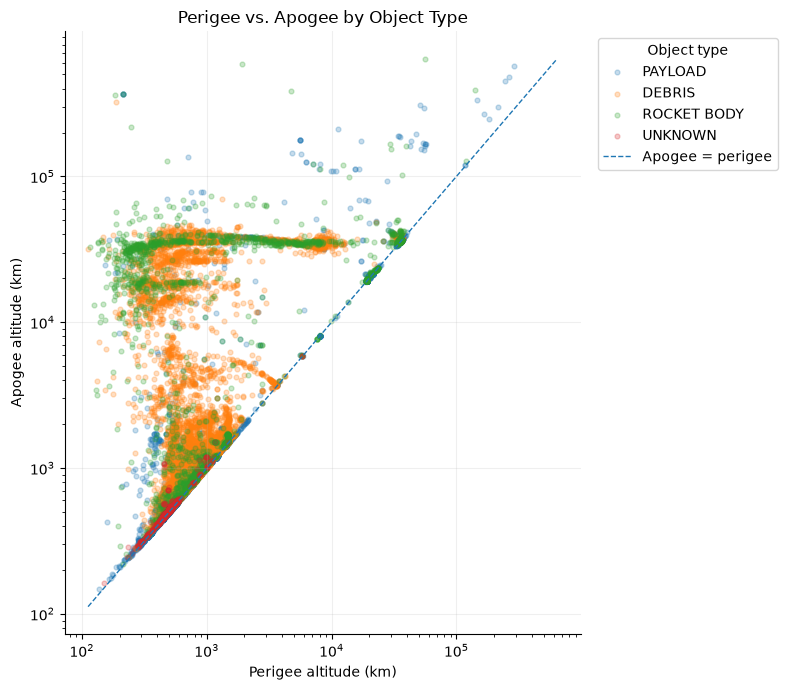

In [43]:
fig, ax = plt.subplots(figsize=(8, 7))

for object_type in object_type_order:
    subset = orbital_analysis_df.loc[
        orbital_analysis_df["OBJECT_TYPE"] == object_type
    ]

    ax.scatter(
        subset["PERIGEE"],
        subset["APOGEE"],
        s=12,
        alpha=0.25,
        label=object_type,
    )

# Reference line for circular or nearly circular orbits.
min_altitude = orbital_analysis_df["PERIGEE"].min()
max_altitude = orbital_analysis_df["APOGEE"].max()

ax.plot(
    [min_altitude, max_altitude],
    [min_altitude, max_altitude],
    linestyle="--",
    linewidth=1,
    label="Apogee = perigee",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Perigee altitude (km)")
ax.set_ylabel("Apogee altitude (km)")
ax.set_title("Perigee vs. Apogee by Object Type")

ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Object type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

The perigee–apogee diagram reveals orbital structure that is hidden by discrete regime labels.

Many objects cluster close to the `apogee = perigee` line, particularly at low altitudes, indicating relatively circular orbits. In contrast, a substantial population of debris and rocket bodies lies far above the diagonal, with low perigees but apogees reaching tens of thousands of kilometers.

A pronounced band of objects with apogees near the geosynchronous-altitude region is also visible. These objects follow highly eccentric trajectories rather than remaining entirely within a single altitude regime.

In [44]:
# Estimate orbital eccentricity from perigee and apogee altitude.
EARTH_RADIUS_KM = 6371.0

r_perigee = EARTH_RADIUS_KM + orbital_analysis_df["PERIGEE"]
r_apogee = EARTH_RADIUS_KM + orbital_analysis_df["APOGEE"]

orbital_analysis_df["ECCENTRICITY_EST"] = (
    (r_apogee - r_perigee)
    / (r_apogee + r_perigee)
)

eccentricity_summary = (
    orbital_analysis_df
    .groupby("OBJECT_TYPE")["ECCENTRICITY_EST"]
    .agg(["median", "mean", "std", "max"])
)

display(eccentricity_summary.round(3))

,median,mean,std,max
OBJECT_TYPE,,,,
DEBRIS,0.010,0.098,0.204,0.961
PAYLOAD,0.000,0.013,0.084,0.965
ROCKET BODY,0.013,0.230,0.301,0.973
UNKNOWN,0.001,0.002,0.004,0.044


The estimated eccentricity confirms the structure observed in the perigee–apogee diagram.

Payloads and unknown objects are concentrated near low-eccentricity orbits, while debris and especially rocket bodies show much broader distributions. Rocket bodies have the highest mean eccentricity (0.230), although their median remains low (0.013), indicating that the difference is driven by a substantial tail of highly eccentric orbits rather than by uniformly eccentric trajectories.

Together, these results show that object types differ not only in the orbital regions they occupy, but also in their orbital geometry.

### Estimated Object Size

The catalog also provides `RCS_SIZE`, a categorical estimate of object size based on radar cross section.

As a final exploratory step, we examine whether the distribution of estimated sizes differs across object types.

In [45]:
# Inspect the coverage and categories of the estimated-size variable.
rcs_summary = pd.Series({
    "Total records": len(space_objects_df),
    "Records with RCS size": space_objects_df["RCS_SIZE"].notna().sum(),
    "Missing RCS size": space_objects_df["RCS_SIZE"].isna().sum(),
    "Unique categories": space_objects_df["RCS_SIZE"].nunique(dropna=True),
})

display(rcs_summary.to_frame("Value"))

display(
    space_objects_df["RCS_SIZE"]
    .value_counts(dropna=False)
    .rename("Objects")
    .to_frame()
)

,Value
Total records,63521
Records with RCS size,53148
Missing RCS size,10373
Unique categories,3


,Objects
RCS_SIZE,
SMALL,24933
LARGE,19345
NaN,10373
MEDIUM,8870


In [46]:
rcs_order = ["SMALL", "MEDIUM", "LARGE"]

rcs_by_type = pd.crosstab(
    space_objects_df["OBJECT_TYPE"],
    space_objects_df["RCS_SIZE"],
)

rcs_by_type = (
    rcs_by_type
    .reindex(object_type_order)
    .reindex(columns=rcs_order, fill_value=0)
)

rcs_by_type_pct = (
    rcs_by_type
    .div(rcs_by_type.sum(axis=1), axis=0)
    .mul(100)
)

display(rcs_by_type)
display(rcs_by_type_pct.round(1))

RCS_SIZE,SMALL,MEDIUM,LARGE
OBJECT_TYPE,,,
PAYLOAD,1591,2677,13749
DEBRIS,22981,5198,1358
ROCKET BODY,34,557,4132
UNKNOWN,327,438,106


RCS_SIZE,SMALL,MEDIUM,LARGE
OBJECT_TYPE,,,
PAYLOAD,8.8,14.9,76.3
DEBRIS,77.8,17.6,4.6
ROCKET BODY,0.7,11.8,87.5
UNKNOWN,37.5,50.3,12.2


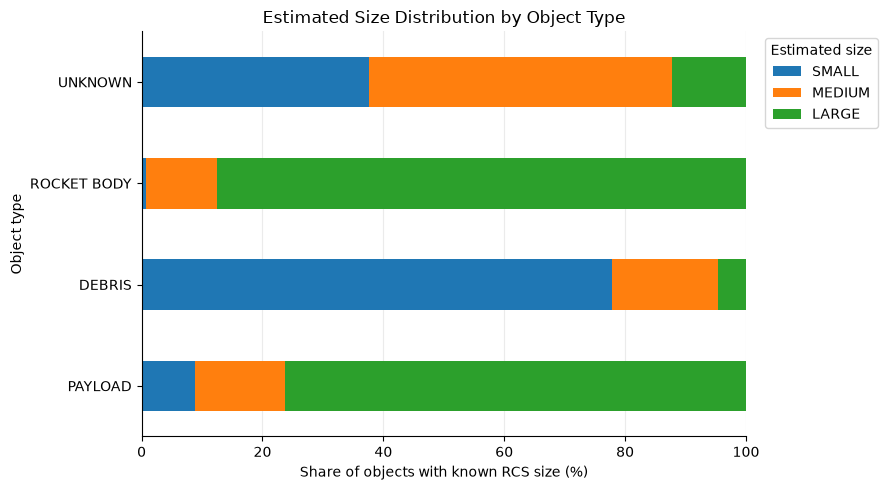

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))

rcs_by_type_pct.plot(
    kind="barh",
    stacked=True,
    ax=ax,
)

ax.set_xlabel("Share of objects with known RCS size (%)")
ax.set_ylabel("Object type")
ax.set_title("Estimated Size Distribution by Object Type")
ax.set_xlim(0, 100)

ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Estimated size",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

Among records with an available `RCS_SIZE` classification, estimated size differs strongly across object types.

Most payloads (76.3%) and rocket bodies (87.5%) are classified as `LARGE`. In contrast, debris is predominantly classified as `SMALL` (77.8%). Unknown objects show a more mixed distribution, with most falling into the `SMALL` or `MEDIUM` categories.

Because `RCS_SIZE` is missing for 10,373 records (16.3% of the catalog), these percentages describe only objects with an available size classification.

## Key Findings

This exploratory analysis reveals several structural patterns in the catalog:

- LEO contains approximately 80% of non-decayed objects with valid orbital information, while about 11.5% follow trajectories that cross multiple altitude regimes.
- Orbital regions differ substantially in composition: the GEO-like region is dominated by payloads, whereas crossing orbits contain mostly debris and rocket bodies.
- Large debris peaks are concentrated in a small number of launch cohorts rather than being distributed uniformly across launch years.
- The recent rise in cataloged payloads reflects both an increase in payload-carrying launches and a strong increase in the number of payloads deployed per launch.
- The composition of cataloged objects differs substantially across responsible country/entity codes.
- Orbital geometry varies by object type, with rocket bodies and debris showing stronger high-eccentricity tails than payloads.
- Estimated object size is also strongly associated with object type: payloads and rocket bodies are predominantly classified as large, while debris is predominantly classified as small.

These findings motivate the next stage of the project: systematic data cleaning and preparation for statistical and machine-learning analysis.